In [174]:
from sklearn.datasets import make_regression
import numpy as np

In [175]:
X,y=make_regression(n_samples=4,n_features=1,n_informative=1,n_targets=1,noise=80,random_state=13)

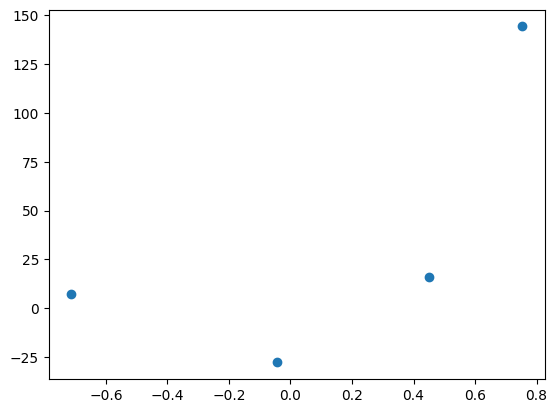

In [176]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [177]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(X,y)

LinearRegression()

In [178]:
reg.coef_

array([78.35063668])

In [179]:
reg.intercept_

np.float64(26.15963284313262)

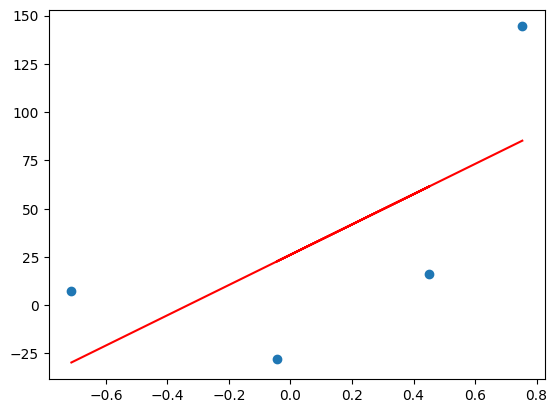

In [180]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color="red")

In [181]:
b=100

In [182]:
#let's apply Gradient Descent assuming slopes is 78.35 
#and let's assume the starting value for intercept b=0
y_pred=((78.35*X)+0).reshape(4)

In [183]:
m=78.35
loss_slope=-2*np.sum(y-m*X.ravel()-b)
lr=0.1
step_size=loss_slope*lr
b=b-step_size
y_pred1=((78.35*X)+b).reshape(4)


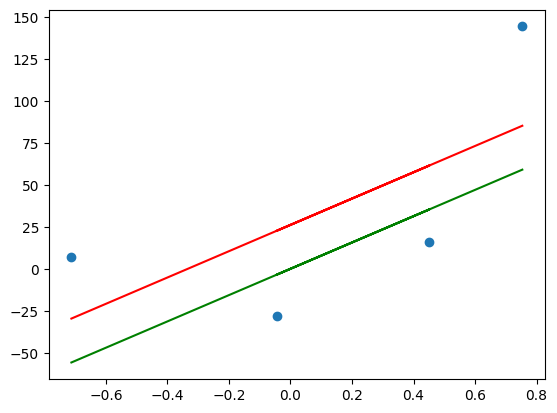

In [184]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label="OLS")
plt.plot(X,y_pred,color='GREEN',label='b=0')
plt.show()

In [185]:
loss_slope=-2*np.sum(y-m*X.ravel()-b)
step_size=lr*loss_slope
b1=b-step_size




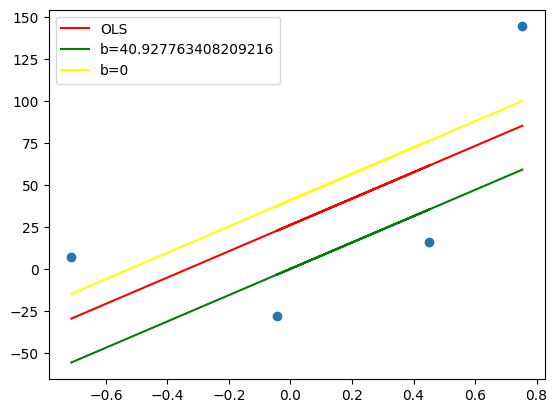

In [186]:
y_pred21=((78.5*X)+b1).reshape(4)
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label="OLS")
plt.plot(X,y_pred,color='GREEN',label='b={}'.format(b))

plt.plot(X,y_pred1,color='yellow',label='b=0')
plt.legend()
plt.show()


In [187]:
loss_slope=-2*np.sum(y-m*X.ravel()-b1)
step_size=lr*loss_slope
b2=b1-step_size
y_pred3=((78.5*X)+b2).reshape(4)

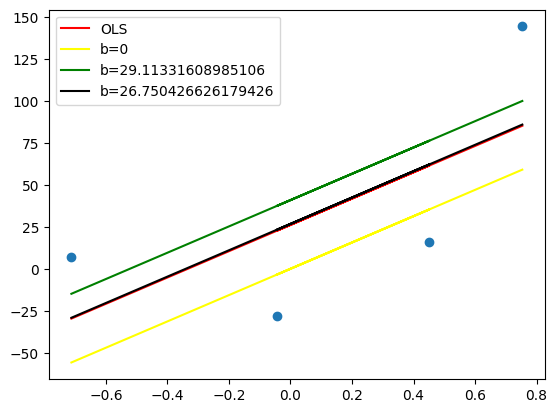

In [188]:
y_pred2=((78.5*X)+b2).reshape(4)
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label="OLS")
plt.plot(X,y_pred,color='yellow',label='b=0')

plt.plot(X,y_pred1,color='GREEN',label='b={}'.format(b1))
plt.plot(X,y_pred2,color='black',label='b={}'.format(b2))

plt.legend()
plt.show()


In [189]:
loss_slope=-2*np.sum(y-m*X.ravel()-b2)
step_size=lr*loss_slope
b3=b2-step_size
y_pred3=((78.5*X)+b3).reshape(4)

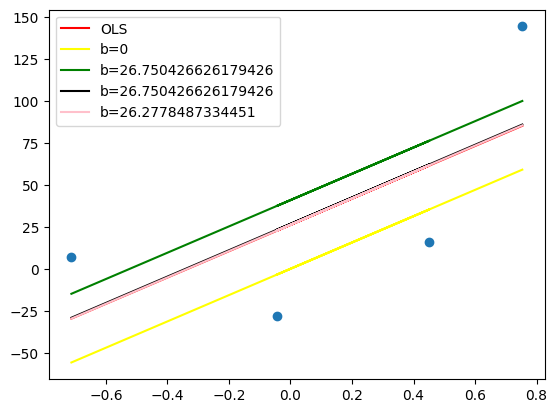

In [190]:

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label="OLS")
plt.plot(X,y_pred,color='yellow',label='b=0')

plt.plot(X,y_pred1,color='GREEN',label='b={}'.format(b2))
plt.plot(X,y_pred2,color='black',label='b={}'.format(b2))
plt.plot(X,y_pred3,color='pink',label='b={}'.format(b3))




plt.legend()
plt.show()


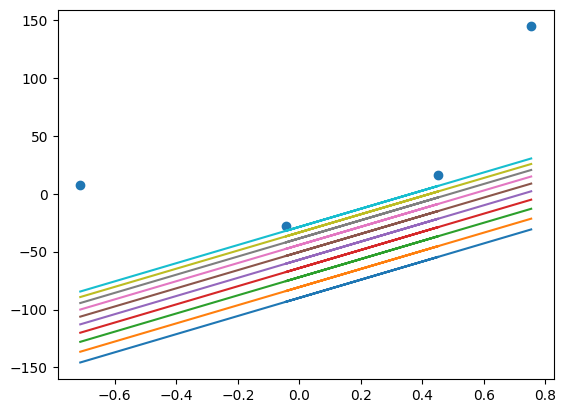

In [191]:
b=-100
m=78.35
lr=0.01
epochs=10
for i in range(epochs):
    loss_slope=-2*np.sum(y-m*X.ravel()-b)
    b=b-(lr*loss_slope)
    y_pred=m*X+b
    plt.plot(X,y_pred)
plt.scatter(X,y)

In [192]:
from sklearn.datasets import make_regression

In [193]:
X,y=make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=42)

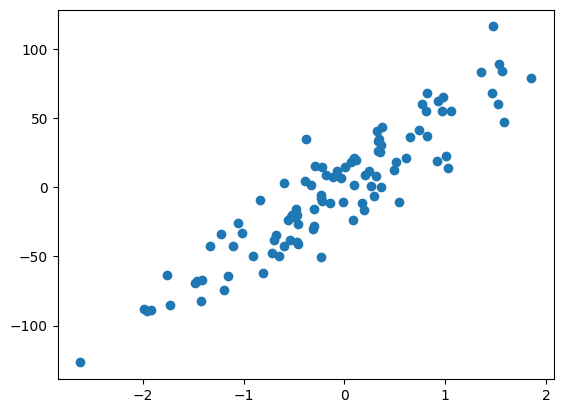

In [194]:
plt.scatter(X,y)

In [195]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X,y)
lr.coef_

array([47.13323967])

In [196]:
lr.intercept_

np.float64(2.3302306410539453)

In [197]:
m=47.13


In [198]:
from sklearn.model_selection import cross_val_score

In [199]:
np.mean(cross_val_score(lr,X,y,scoring="r2",cv=10))

np.float64(0.8016058585014069)

In [210]:
class GDRegressor:
    def __init__(self,learningRate,epochs):
        self.m=100
        self.b=-120
        self.lr=learningRate
        self.epochs=epochs
        
        
    def fit(self,X,y):
        #calculate b using gradient descend
        for i in range(self.epochs):
           loss_slope_b=-2*np.sum(y-self.m*X.ravel()-self.b)
           loss_slope_m=-2*np.sum(y-self.m*X.ravel()-self.b)*X.ravel()
           self.b=self.b-(self.lr*loss_slope_b)
           self.m=self.m-(self.lr*loss_slope_m)
        print(self.m,self.b)
           
           
    def predict(self,X):
        return self.m*X+self.b
            


In [211]:
gd=GDRegressor(0.001,100)
gd.fit(X,y)
gd.predict(X)


[165.14313828 106.0889512   26.01301382 121.98163262  66.48171373
 145.30587858  67.58388564 137.95212978 142.78681811 170.19722744
 157.49216309 207.58581298 151.65581176  84.63392929  43.44579092
 106.41867558 -37.07912285 135.90310872 172.1185206  -83.2514343
 134.74520511 106.79058437  67.42215676 164.03247048 209.44698156
 202.52227923  57.98526305  97.49396495  57.91056178  16.32522598
 124.9800604  126.28011428 118.26084262  62.94322031  36.48362432
 113.77046331  79.08440567 125.29647643 157.53709958  79.59599278
 125.27965906  52.64923779 206.53609209  63.74694595  83.62094782
  72.57199513  78.93776612  54.87380809 122.99617328 114.61002954
  77.07999979 100.35768681  83.62209624 203.37883751  73.06345564
 124.03613402 123.17191044  87.01313585  83.59060636 -39.03064607
 122.66970635  84.20692501  22.61175697  50.89131526  -2.37301826
 167.7568148  -20.65817639 -33.83414612  60.66793061 153.68213672
 156.83626324   1.20921362  -3.42276237  14.60186353  41.29664959
 210.466095

array([[ 103.74462236,   48.74863199,  -25.82449651, ...,   -3.81479802,
          38.38714748,   22.93504823],
       [ -35.6746731 ,  -40.81516695,  -47.78554253, ...,  -45.72828856,
         -41.78365842,  -43.22797137],
       [-224.72360132, -162.26134225,  -77.56414814, ..., -102.56188852,
        -150.49318015, -132.94330024],
       ...,
       [-168.92723077, -126.41741622,  -68.77521647, ...,  -85.78787857,
        -118.40838171, -106.46449509],
       [ -61.94187659,  -57.6893774 ,  -51.92309941, ...,  -53.62497303,
         -56.888188  ,  -55.6933729 ],
       [-101.11420127,  -82.85391578,  -58.09344493, ...,  -65.40131184,
         -79.41359833,  -74.28304714]], shape=(100, 100))